The goal is to predict the noise level of a noisy image so it can be passed into a pretrained diffusion model.

# Load deps

In [ ]:
# ! pip install -q torcheval

In [41]:
# # # if src modules imported
# # from google.colab import drive
# # drive.mount('/content/drive')
# import sys
# app_path = '/content/drive/MyDrive/Projects/miniSD'
# sys.path.append(app_path)

In [ ]:
import os, torch, math
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from fastprogress import progress_bar
from datasets import load_dataset
from torch.utils.data import DataLoader,default_collate
from torch import nn, optim
from functools import partial
from diffusers import UNet2DModel

from src.learner import to_cpu
from src.utils import set_seed
from src.datasets import inplace, DataLoaders, show_images
from src.learner import DeviceCB, ProgressCB, MetricsCB, Learner, TrainLearner
from src.accel import MixedPrecision
from src.sgd import BatchSchedCB
from src.fid import ImageEval
from src.resnet import ResBlock
from src.init import GeneralRelu, init_weights
from src.diffusion import init_ddpm

# Config

In [ ]:
mpl.rcParams['image.cmap'] = 'gray_r'
mpl.rcParams['figure.dpi'] = 70
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
dataset_xl,dataset_yl = 'image','label'
dataset_name = "fashion_mnist"
bs = 512
lr = 1e-2
epochs = 10
models_path = Path("artifacts/models")
models_path.mkdir(exist_ok=True, parents=True)
os.environ['CUDA_VISIBLE_DEVICES']='1'
set_seed(42)

# Load dataset

- Here, we're buidling a different model
- This model predicts the amount of noise (logit of `alpha_bar`) given the noisy image
- So, the dataloader yiled the noisy image as independent and the noise level as the dependent variable

In [ ]:
def noisify(x0):
    device = x0.device
    al_t = torch.rand((len(x0), 1, 1, 1), device=device)
    ε = torch.randn(x0.shape, device=device)
    xt = al_t.sqrt()*x0 + (1-al_t).sqrt()*ε
    return xt,al_t.squeeze().logit()
    # we won't use sigmoid activation for the last layer anymore.
    # TODO: does this work better than using a sigmoid as the last layer's activation?

def collate_ddpm(b): return noisify(default_collate(b)[dataset_xl])
def dl_ddpm(ds): return DataLoader(
    ds, batch_size=bs,
    collate_fn=collate_ddpm,
    num_workers=os.cpu_count()
)

@inplace
def transformi(b):
    b[dataset_xl] = [
        F.pad(TF.to_tensor(o), (2,2,2,2))-0.5
        for o in b[dataset_xl]
    ]

In [ ]:
dsd = load_dataset(dataset_name)
tds = dsd.with_transform(transformi)
dls = DataLoaders(
    dl_ddpm(tds['train']),
    dl_ddpm(tds['test'])
)
dl = dls.train
xt,amt = next(iter(dl))

In [ ]:
titles = [f'{o:.2f}' for o in amt[:16]]
show_images(xt[:16], imsize=1.7, titles=titles);

# Measuring the baseline performance

In [ ]:
class f(nn.Module):
    def __init__(self):
        super().__init__()
        self.blah = nn.Linear(1,1)
    def forward(self,x): return torch.full((len(x),), 0.0)
    # this is the baseline model predicting zero logit for all records
learn = TrainLearner(f(), dls, F.mse_loss, lr=lr, cbs=[MetricsCB()])
learn.fit(1, train=False)

In [ ]:
def flat_mse(x,y): return F.mse_loss(x.flatten(), y.flatten())
learn = TrainLearner(f(), dls, flat_mse, lr=lr, cbs=[MetricsCB()])
learn.fit(1, train=False)

# Train noise prediction model

In [ ]:
def get_model(act=nn.ReLU, nfs=(16,32,64,128,256,512), norm=nn.BatchNorm2d):
    layers = [ResBlock(1, 16, ks=5, stride=1, act=act, norm=norm)]
    layers += [ResBlock(nfs[i], nfs[i+1], act=act, norm=norm, stride=2) for i in range(len(nfs)-1)]
    layers += [nn.Flatten(), nn.Dropout(0.2), nn.Linear(nfs[-1], 1, bias=False)]
    # last layer outputs a single number as the logit
    return nn.Sequential(*layers)

In [ ]:
opt_func = partial(optim.Adam, eps=1e-5)
tmax = epochs * len(dls.train)
sched = partial(optim.lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
cbs = [DeviceCB(), MetricsCB(), ProgressCB(plot=True)]
xtra = [BatchSchedCB(sched)]
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
iw = partial(init_weights, leaky=0.1)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, flat_mse, lr=lr, cbs=cbs+xtra, opt_func=opt_func)

In [ ]:
# learn.fit(epochs)

# Save and load model

In [ ]:
# torch.save(learn.model, models_path / 'noisepred_sig.pkl')

In [ ]:
tmodel = learn.model
tmodel = torch.load(models_path / 'noisepred_sig.pkl', weights_only=False).cuda()

# Measure the noise prediction performance visually

In [ ]:
with torch.no_grad(): a = to_cpu(tmodel(xt.cuda()).squeeze())
titles = [f'{o.sigmoid():.2f}|gt={gt.sigmoid():.2f}' for o,gt in zip(a[:16], amt[:16])]
show_images(xt[:16], imsize=1.7, titles=titles);

# Train No-time diffusion model

In [ ]:
def abar(t): return (t*math.pi/2).cos()**2
def inv_abar(x): return x.sqrt().acos()*2/math.pi

def noisify(x0):
    device = x0.device
    n = len(x0)
    t = torch.rand((n,)).to(x0).clamp(0,0.999)
    ε = torch.randn(x0.shape).to(x0)
    abar_t = abar(t).reshape(-1, 1, 1, 1).to(device)
    xt = abar_t.sqrt()*x0 + (1-abar_t).sqrt()*ε
    return xt, ε # we don't return t anymore

In [ ]:
class UNet(UNet2DModel):
    def forward(self, x): return super().forward(x,0).sample
    # since we don't have t anymore, we set it to 0
    # for experimentation purposes this is good enough
    # a better way would be to change the architecture a bit so it doesn't expect t.

In [ ]:
lr = 4e-3
epochs = 25
tmax = epochs * len(dls.train)
sched = partial(optim.lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
cbs = [DeviceCB(), MixedPrecision(), ProgressCB(plot=True), MetricsCB(), BatchSchedCB(sched)]
model = UNet(in_channels=1, out_channels=1, block_out_channels=(32, 64, 128, 256), norm_num_groups=8)
init_ddpm(model)
learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)

In [ ]:
# learn.fit(epochs)

## Save and load model

In [ ]:
# torch.save(learn.model, models_path/'fashion_no-t.pkl')

In [ ]:
model = learn.model = torch.load(
    models_path/'fashion_no-t.pkl',
    weights_only=False
).cuda()

# # make sure we load the correct model by checking the eval loss (~0.03-0.35)
# learn.fit(n_epochs=1, train=False)

# Sampling from No-time model

## Load the reference model

In [ ]:
from src.augment import get_dropmodel, Dropout
from src.augment import capture_preds
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
iw = partial(init_weights, leaky=0.1)
cmodel = get_dropmodel(act_gr, norm=nn.BatchNorm2d, drop=0.1).apply(iw)
loaded_art = torch.load(models_path / 'data_aug2.pkl', weights_only=False)
cmodel.load_state_dict(loaded_art.state_dict())
cmodel = cmodel[:-3]

In [ ]:
@inplace
def transformi2(b): b[dataset_xl] = [
    F.pad(TF.to_tensor(o), (2,2,2,2))*2-1
    for o in b[dataset_xl]
]
bs = 2048
tds = dsd.with_transform(transformi2)
dls = DataLoaders.from_dd(tds, bs, num_workers=os.cpu_count())

dt = dls.train
xb,yb = next(iter(dt))

ie = ImageEval(cmodel, dls, cbs=[DeviceCB()])

## Modified sampler definition 1

In [ ]:
def ddim_step(x_t, noise, abar_t, abar_t1, bbar_t, bbar_t1, eta):
    sig = ((bbar_t1/bbar_t).sqrt() * (1-abar_t/abar_t1).sqrt()) * eta
    x_0_hat = ((x_t-(1-abar_t).sqrt()*noise) / abar_t.sqrt()).clamp(-0.5,0.5)
    if bbar_t1<=sig**2+0.01: sig=0.  # set to zero if very small or NaN
    # TODO: what happens if we remove the above line?
    x_t = abar_t1.sqrt()*x_0_hat + (bbar_t1-sig**2).sqrt()*noise
    x_t += sig * torch.randn(x_t.shape).to(x_t)
    return x_0_hat, x_t

In [ ]:
@torch.no_grad()
def sample(f, model, sz, steps, eta=1.):
    ts = torch.linspace(1-1/steps,0,steps)
    x_t = torch.randn(sz).to(model.device)
    preds = []
    for i,t in enumerate(progress_bar(ts)):
        abar_t = abar(t)
        noise = model(x_t) # we don't pass t here
        abar_t1 = abar(t-1/steps) if t>=1/steps else torch.tensor(1)
        x_0_hat,x_t = f(x_t, noise, abar_t, abar_t1, 1-abar_t, 1-abar_t1, eta)
        preds.append(x_0_hat.float().cpu())
    return preds

## Measure the sampling performance

In [ ]:
sz = (bs,1,32,32)
print(f"sample size: {sz}")

In [ ]:
# # set_seed(42)
preds = sample(ddim_step, model, sz, steps=100, eta=1.)
print(preds[-1].shape)

In [ ]:
s = (preds[-1]*2)
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")
# show_images(s[:16], imsize=1.5);

- sampled images fid: 39.79949951171875, kid: 0.22138288617134094
- real images fid: -0.025390625, kid: 0.006897286511957645

- The performance is too bad!!!
- The problem is that the new model doesn't know exactly how much noise to remove from each image
- This is because even though it can predict the total noise accurately, it doesn't have timestep
    - it predicts the average noise accurately but have a variance over different records (with different timesteps!!)
- So, we're going to use the noise prediction model (`tmodel`) to estimate `alphabar` and calculate `t` from it.

## Modified sampler definition 2

In [ ]:
def ddim_step(x_t, noise, abar_t, abar_t1, bbar_t, bbar_t1, eta):
    sig = ((bbar_t1/bbar_t).sqrt() * (1-abar_t/abar_t1).sqrt()) * eta
    with torch.no_grad(): a = tmodel(x_t)[...,None,None].sigmoid()
    med = a.median()
    a = a.clamp(med/2,med*2)
    x_0_hat = ((x_t-(1-a).sqrt()*noise) / a.sqrt()).clamp(-0.5,0.5)
    if bbar_t1<=sig**2+0.01: sig=0.
    x_t = abar_t1.sqrt()*x_0_hat + (bbar_t1-sig**2).sqrt()*noise
    x_t += sig * torch.randn(x_t.shape).to(x_t)
    return x_0_hat,x_t

In [ ]:
# set_seed(42)
preds = sample(ddim_step, model, sz, steps=100, eta=1.)
print(preds[-1].shape)

In [ ]:
s = (preds[-1]*2)
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")

- sampled images fid: 102.8502197265625, kid: 0.583311140537262
- real images fid: -0.025390625, kid: 0.006897286511957645

- based on [jeremy's video](https://www.youtube.com/watch?v=6Bta1tXRUfM)(25:30) this should fix the problem
- but it doesn't. in fact, this made the performance worse :))
- i will try another idea below

## Modified sampler definition 3

In [ ]:
@torch.no_grad()
def sample(f, model, sz, steps, eta=1.):
    ts = torch.linspace(1-1/steps,0,steps)
    x_t = torch.randn(sz).to(model.device)
    preds = []
    for i,t in enumerate(progress_bar(ts)):
        noise = model(x_t) # we don't pass t here
        abar_t1 = abar(t-1/steps) if t>=1/steps else torch.tensor(1)
        x_0_hat,x_t = f(x_t, noise, abar_t1, eta)
        preds.append(x_0_hat.float().cpu())
    return preds

def ddim_step(x_t, noise, abar_t1, eta):
    with torch.no_grad(): a = tmodel(x_t)[...,None,None].sigmoid()
    med = a.median()
    a = a.clamp(med/2,med*2)
    t = inv_abar(a)
    at1 = abar(t-1/100)
    at1[t<1/100]=1
    sig = (((1-at1)/(1-a)).sqrt() * (1-a/at1).sqrt()) * eta
    sig[torch.isnan(sig)] = 0
    x_0_hat = ((x_t-(1-a).sqrt()*noise) / a.sqrt())

    abar_t1 = at1
    bbar_t1 = 1 - abar_t1

    sig[bbar_t1<=sig**2+0.01]=0.
    x_t = abar_t1.sqrt()*x_0_hat + (bbar_t1-sig**2).sqrt()*noise
    x_t += sig * torch.randn(x_t.shape).to(x_t)
    return x_0_hat,x_t

In [ ]:
from src.init import clean_mem
clean_mem()
preds = sample(ddim_step, model, sz, steps=100, eta=1.)
print(preds[-1].shape)
s = (preds[-1]*2)
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")

this is much better; close enough to 3.8 which jeremy achieved in the video
- sampled images fid: 3.73114013671875, kid: 0.008040032349526882
- real images fid: -0.025390625, kid: 0.006897286511957645

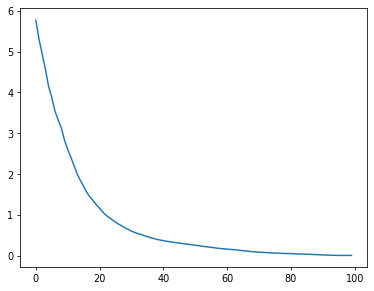

In [42]:
plt.plot([ie.kid((o*2).clamp(-1,1)) for o in preds]);

- In contrast to jeremy's results, where `kid` gets worse in the beginning before starting to decline, we got a smooth descreaing curve!!!